In [33]:
# Data drifters overview

# Imports
import os
import pandas as pd
import cartopy.crs as ccrs
# from matplotlib.patches import Patch  
from cartopy.feature import NaturalEarthFeature
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import Polygon, MultiPolygon
import geopandas as gpd
import cartopy.io.shapereader as shpreader
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [34]:
# Paths
DATA_PATH = "/home/rosquete/Documents/FRESH-CARE/data/fusion_evaluation/classic_evaluation/in_situ_data/data_ready/"
OUTPUT_PATH = "/home/rosquete/Documents/FRESH-CARE/data/fusion_evaluation/classic_evaluation/in_situ_data/" 
regions_info = "/home/rosquete/Documents/FRESH-CARE/regions/delimitation/arctic_regions.json"

In [35]:
# Functions

def read_drifter_file(file_path):
    """
    Reads a drifter file and returns its trajectory
    """
    with open(file_path, 'r') as f:
        lines = f.readlines()
    
    # Find the line where the header line
    data_start = None
    for i, line in enumerate(lines):
        if line.startswith('time,latitude,lon360'):
            data_start = i
            break
    
    if data_start is None:
        return None

    # Read the data into a DataFrame
    df = pd.read_csv(file_path, skiprows=data_start)

    df['time'] = pd.to_datetime(df['time'])
    drifter_id = os.path.basename(file_path).replace('.csv', '')

    return df, drifter_id

def prepare_drifters(valid_drifters):
    """
    Converts lon360 to longitude [-180, 180] for plotting.
    No drifters are discarded — cartopy handles all meridian crossings correctly
    when coordinates are plotted segment-by-segment without large jumps.
    For each drifter, inserts NaN rows at any longitude jump > 10° so matplotlib
    breaks the line there instead of drawing an artifact across the map.
    """
    clean_drifters = []

    for df, drifter_id in valid_drifters:
        df = df.copy()
        # Convert lon360 -> [-180, 180]
        df['longitude'] = (df['lon360'] + 180) % 360 - 180

        lons = df['longitude'].values
        jumps = np.where(np.abs(np.diff(lons)) > 10)[0] + 1  # indices after jump

        if len(jumps) > 0:
            # Insert NaN rows at each jump so matplotlib breaks the line
            nan_row = {col: np.nan for col in df.columns}
            nan_row['time'] = pd.NaT
            inserts = []
            for idx in jumps:
                inserts.append((idx, pd.DataFrame([nan_row])))
            # Insert from back to front to preserve indices
            for idx, nan_df in sorted(inserts, reverse=True):
                df = pd.concat([df.iloc[:idx], nan_df, df.iloc[idx:]], ignore_index=True)

        clean_drifters.append((df, drifter_id))

    return clean_drifters

def densify_polygon_coords(coords, n_points=50):
    """
    Densify polygon coordinates: for each segment with constant latitude or longitude,
    interpolate intermediate points to make arcs appear smooth in polar projection.
    """
    new_coords = []
    for i in range(len(coords) - 1):
        lon1, lat1 = coords[i]
        lon2, lat2 = coords[i + 1]
        # If lat is constant (parallel), interpolate in longitude
        if np.isclose(lat1, lat2) and not np.isclose(lon1, lon2):
            lons = np.linspace(lon1, lon2, n_points)
            lats = np.full_like(lons, lat1)
            new_coords.extend(list(zip(lons, lats)))
        # If lon is constant (meridian), interpolate in latitude
        elif np.isclose(lon1, lon2) and not np.isclose(lat1, lat2):
            lats = np.linspace(lat1, lat2, n_points)
            lons = np.full_like(lats, lon1)
            new_coords.extend(list(zip(lons, lats)))
        else:
            # Diagonal or irregular segment, just add endpoints
            new_coords.append((lon1, lat1))
    # Add last point
    new_coords.append(coords[-1])
    return new_coords

def densify_geodataframe(gdf, n_points=50):
    """
    Return a copy of the GeoDataFrame with densified polygons for smooth polar plotting.
    """
    densified_geoms = []
    for geom in gdf.geometry:
        if geom.geom_type == 'Polygon':
            exterior = densify_polygon_coords(list(geom.exterior.coords), n_points)
            interiors = [densify_polygon_coords(list(ring.coords), n_points) for ring in geom.interiors]
            densified_geoms.append(Polygon(exterior, interiors))
        elif geom.geom_type == 'MultiPolygon':
            parts = []
            for poly in geom.geoms:
                exterior = densify_polygon_coords(list(poly.exterior.coords), n_points)
                interiors = [densify_polygon_coords(list(ring.coords), n_points) for ring in poly.interiors]
                parts.append(Polygon(exterior, interiors))
            densified_geoms.append(MultiPolygon(parts))
        else:
            densified_geoms.append(geom)
    gdf2 = gdf.copy()
    gdf2.geometry = densified_geoms
    return gdf2


def plot_trajectories(valid_drifters, figsize=(9, 9), cbar_pos=(0.90, 0.62), cbar_size=(0.028, 0.32)):
    """
    Plots drifters trajectories on a map with region polygons.
    Trajectories are colored by speed using a YlGnBu colormap.

    cbar_pos: (x, y) float tuple in axes coordinates (lower-left corner).
    cbar_size: (width, height) float tuple in axes fraction.
    """

    # Load and densify regions
    gdf = gpd.read_file(regions_info)
    gdf = densify_geodataframe(gdf)

    # Arctic polar projection
    proj = ccrs.NorthPolarStereo()
    fig = plt.figure(figsize=figsize)
    ax = plt.axes(projection=proj)
    ax.set_extent([-180, 180, 48, 90], crs=ccrs.PlateCarree())

    # Add ocean and land
    ocean = NaturalEarthFeature("physical", "ocean", "50m", facecolor="white", zorder=1)
    land = NaturalEarthFeature("physical", "land", "50m", facecolor="lightgray", zorder=4)
    ax.add_feature(ocean)
    ax.add_feature(land)
    ax.coastlines(resolution="50m", zorder=4.5, linewidth=0.6)

    # Project regions
    gdf_proj = gdf.to_crs(proj.proj4_init)
    ids = gdf_proj["id"].astype(str).unique()

    # # Tab20-based palette for regions 
    # tab20 = mpl.colormaps["tab20"]
    # tab20_colors = [mpl.colors.to_hex(tab20(i / max(tab20.N - 1, 1))) for i in range(tab20.N)]
    # preferred_indices = {
    #     "S1": 0, "S2": 2, "S3": 4, "S4": 6, "S5": 8, "S6": 10, "S7": 12, "S8": 18,
    #     "S9": 16, "S10": 3, "S11": 5, "S12": 7, "S13": 9, "S14": 11,
    # }
    # used_indices = set(preferred_indices.values())
    # fallback_indices = [i for i in range(tab20.N) if i not in used_indices]
    # fallback_iter = iter(fallback_indices)
    # color_map = {}
    # for cat in ids:
    #     idx = preferred_indices.get(cat)
    #     if idx is not None:
    #         color_map[cat] = tab20_colors[idx]
    #     else:
    #         idx = next(fallback_iter, None)
    #         if idx is None:
    #             idx = 0
    #         color_map[cat] = tab20_colors[idx]
    # facecolors = gdf_proj["id"].map(color_map)

    # # Plot regions with fill colors (now only plotting borders)
    # s10_mask = gdf_proj["id"].astype(str) == "S10"
    # if s10_mask.any():
    #     gdf_proj[s10_mask].plot(
    #         ax=ax, color=facecolors[s10_mask], edgecolor="none", linewidth=0,
    #         alpha=0.7, legend=False, zorder=1,
    #     )
    # gdf_proj[~s10_mask].plot(
    #     ax=ax, color=facecolors[~s10_mask], edgecolor="k", linewidth=0.8,
    #     alpha=0.7, legend=False, zorder=1,
    # )

    # # Region border plotting moved to end so it's painted after trajectories
    # gdf_proj.plot(
    #     ax=ax, color="none", edgecolor="k", linewidth=0.8,
    #     legend=False, zorder=3,
    # )

    # Add region labels
    land_shp = shpreader.natural_earth(resolution="50m", category="physical", name="land")
    land_gdf = gpd.read_file(land_shp)
    land_gdf = land_gdf.to_crs(proj.proj4_init)
    land_union = land_gdf.union_all()

    for _, row in gdf_proj.iterrows():
        poly_id = row["id"]
        label = str(poly_id)
        geom = row.geometry
        if label == "S9":
            continue
        if geom.geom_type == "MultiPolygon":
            base_poly = max(geom.geoms, key=lambda g: g.area)
        elif geom.geom_type == "Polygon":
            base_poly = geom
        else:
            continue
        try:
            ocean_part = base_poly.difference(land_union)
        except Exception:
            ocean_part = base_poly
        label_point = None
        if not ocean_part.is_empty:
            if ocean_part.geom_type == "Polygon":
                label_point = ocean_part.representative_point()
            elif ocean_part.geom_type == "MultiPolygon":
                largest_ocean = max(ocean_part.geoms, key=lambda g: g.area)
                label_point = largest_ocean.representative_point()
        if label_point is None or label_point.is_empty:
            label_point = base_poly.representative_point() if not base_poly.is_empty else None
            if (label_point is None) or label_point.is_empty:
                continue
        ax.text(
            label_point.x, label_point.y, label,
            fontsize=10, fontweight="bold", color="black",
            ha="center", va="center", transform=proj, zorder=5,
        )

    ax.text(
        -99.0, 65.0, "S9",
        transform=ccrs.PlateCarree(),
        fontsize=10, fontweight="bold", color="black",
        ha="center", va="center", zorder=5,
    )

    # # Custom legend for regions (replaced with speed colorbar)
    # handles = [
    #     Patch(facecolor=color_map[cat], edgecolor="0.4", linewidth=0.6, label=cat, alpha=0.6)
    #     for cat in ids
    # ]
    # leg = ax.legend(
    #     handles=handles, title="Regions", loc="upper right", bbox_to_anchor=(0.9, 0.75),
    #     frameon=True, fontsize=10,
    # )
    # leg.set_zorder(200)
    # leg.get_frame().set_alpha(0.8)
    # leg.get_title().set_fontsize(11)


    # Calculate global speed limits across all drifters
    all_speeds = []
    for df, _ in valid_drifters:
        speeds = df['speed'].dropna().values
        all_speeds.extend(speeds)

    # Normalization (percentiles) to improve color contrast
    if len(all_speeds) > 0:
        speed_min, speed_max = np.percentile(all_speeds, [2, 98])
        if np.isclose(speed_min, speed_max):
            speed_min, speed_max = np.min(all_speeds), np.max(all_speeds)
    else:
        speed_min, speed_max = 0, 1

    # Create colormap and normalization
    cmap = plt.cm.YlGnBu
    norm = mpl.colors.Normalize(vmin=speed_min, vmax=speed_max, clip=True)

    # Plot drifter trajectories 
    for df, drifter_id in valid_drifters:
        lons = df['longitude'].values
        lats = df['latitude'].values
        speeds = df['speed'].values

        # Plot each segment with color based on speed
        for i in range(len(lons) - 1):
            # Skip segments with NaN values
            if np.isnan(lons[i]) or np.isnan(lons[i+1]) or np.isnan(speeds[i]):
                continue

            color = cmap(norm(speeds[i]))
            ax.plot([lons[i], lons[i+1]], [lats[i], lats[i+1]],
                    color=color, alpha=0.65, linewidth=0.8,
                    transform=ccrs.PlateCarree(), zorder=2)

    # Add colorbar using float position (axes coordinates)
    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cax = ax.inset_axes([cbar_pos[0], cbar_pos[1], cbar_size[0], cbar_size[1]], transform=ax.transAxes)
    cbar = plt.colorbar(sm, cax=cax, orientation='vertical')
    cbar.set_label('Drifter speed (m/s)', fontsize=12)

    # Plot region borders excluding S10 to avoid central-circle seam artifacts
    region_edges = gdf_proj[gdf_proj["id"].astype(str) != "S10"]
    region_edges.plot(
        ax=ax, color="none", edgecolor="k", linewidth=0.9,
        legend=False, zorder=3,
    )

    
    # Boundary circle 
    theta = np.linspace(0, 2 * np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)


    # Gridlines
    gl = ax.gridlines(draw_labels=True, color='gray', alpha=0.3, zorder=300)

    gl.xlabel_style = {'size': 11, 'color': '#000000'}
    gl.ylabel_style = {'size': 11, 'color': '#000000'}

    gl.top_labels = True
    gl.right_labels = True
    gl.bottom_labels = True
    gl.left_labels = True

    fig.canvas.draw()

    for artist in gl.xline_artists + gl.yline_artists:
        artist.set_zorder(300)

    for artist in gl.xlabel_artists + gl.ylabel_artists:
        artist.set_zorder(301)
        artist.set_clip_on(False)

    plt.tight_layout()

    return fig, ax


Found 742 CSV files to process...
✓ Added 104126: 60 points
✓ Added 300234066512810: 100 points
✓ Added 300234066414750: 127 points
✓ Added 300534061759270: 66 points
✓ Added 300534061181960: 28 points
✓ Added 132488: 377 points
✓ Added 83468: 39 points
✓ Added 300234062857970: 408 points
✓ Added 300234066516010: 695 points
✓ Added 300234065800030: 54 points
✓ Added 300234066394370: 142 points
✓ Added 300234066514780: 62 points
✓ Added 300234064502410: 88 points
✓ Added 300234066516000: 191 points
✓ Added 300234068343000: 128 points
✓ Added 300234067205870: 114 points
✓ Added 300234063321250: 31 points
✓ Added 145895: 443 points
✓ Added 300234067906400: 92 points
✓ Added 300234011910520: 75 points
✓ Added 300234011548420: 119 points
✓ Added 300534061182960: 27 points
✓ Added 300234068345210: 86 points
✓ Added 79325: 379 points
✓ Added 300234067204880: 95 points
✓ Added 300234068345220: 68 points
✓ Added 300234068346490: 101 points
✓ Added 300234066414920: 202 points
✓ Added 30053406071

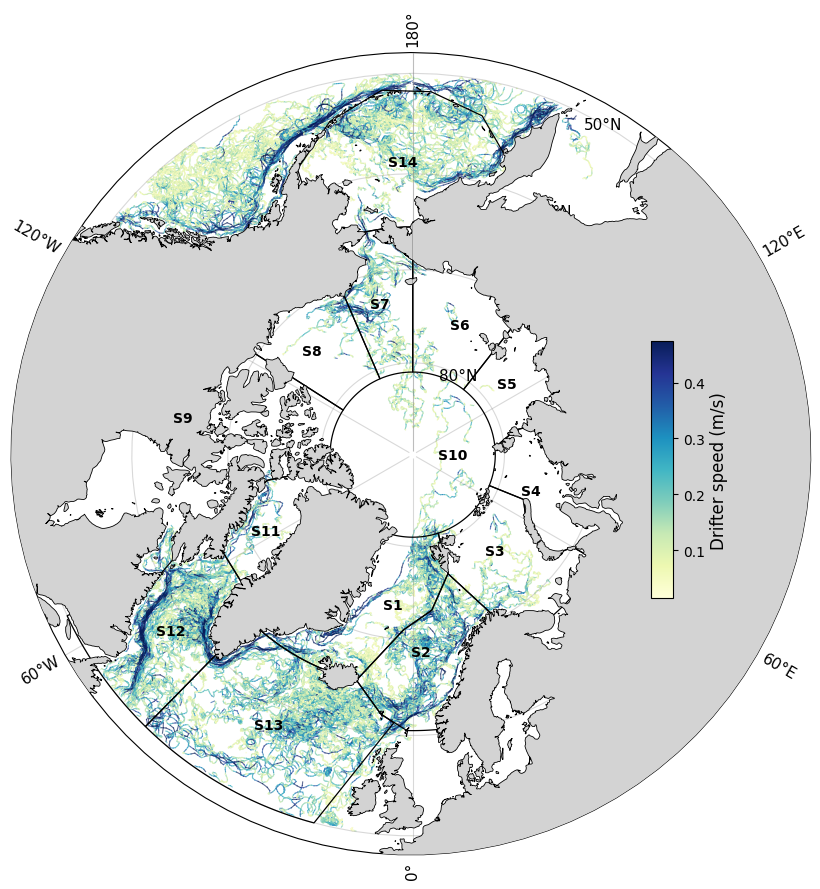

Overview map saved to: /home/rosquete/Documents/FRESH-CARE/data/fusion_evaluation/classic_evaluation/in_situ_data/


In [36]:
# Main execution
if __name__ == "__main__":

    # Read all CSV drifter files from DATA_PATH 
    csv_files = [f for f in os.listdir(DATA_PATH) if f.lower().endswith('.csv')]
    print(f"Found {len(csv_files)} CSV files to process...")

    valid_drifters = []
    for file in csv_files:
        file_path = os.path.join(DATA_PATH, file)
        result = read_drifter_file(file_path)
        if result is None:
            print(f"✗ Skipping {file}: couldn't read data")
            continue

        df, drifter_id = result
        if df is None or len(df) == 0:
            print(f"✗ Skipping {drifter_id}: no data")
            continue

        valid_drifters.append((df, drifter_id))
        print(f"✓ Added {drifter_id}: {len(df)} points")

    print(f"\nFound {len(valid_drifters)} valid drifters")

    # Prepare drifters for plotting (convert lon360, break lines at meridian crossings)
    print("\nPreparing drifters for plotting...")
    clean_drifters = prepare_drifters(valid_drifters)

    print(f"Ready to plot: {len(clean_drifters)} drifters")

    if clean_drifters:
        # Generate overview map with all trajectories
        # cbar_pos=(x, y) and cbar_size=(w, h) are floats in axes fraction
        print("\nGenerating overview map...")
        fig, ax = plot_trajectories(clean_drifters, cbar_pos=(0.80, 0.32), cbar_size=(0.028, 0.32))

        fig.savefig(OUTPUT_PATH+"drifter_trajectories_arctic_clean.png",
                    dpi=500, bbox_inches='tight')
        plt.show()

        print(f'Overview map saved to: {OUTPUT_PATH}')